<a href="https://colab.research.google.com/github/apekshatembhurne28-hash/apekshatembhurne28-ApekshaFML-practicals/blob/main/Task10_EE504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

**4A**

In [ ]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.4173532894201708
2/(50, error=0.20802221692448464
3/(50, error=0.08413655191800261
4/(50, error=0.03258254997660713
5/(50, error=0.13869102951148737
6/(50, error=0.08686245478472507
7/(50, error=0.11398460447621624
8/(50, error=0.08251090665974213
9/(50, error=0.06936300300142598
10/(50, error=0.04822329555048966
11/(50, error=0.034037966949636005
12/(50, error=0.020747658015740494
13/(50, error=0.01222562205702967
14/(50, error=0.00736683587223245
15/(50, error=0.005228184669478611
16/(50, error=0.00460259188335977
17/(50, error=0.004951136148748537
18/(50, error=0.00595246306180627
19/(50, error=0.007438615109766912
20/(50, error=0.009237372773379413
21/(50, error=0.011179797633300377
22/(50, error=0.013079497297936712
23/(50, error=0.014748781644339728
24/(50, error=0.016020947372984425
25/(50, error=0.016789550122028797
26/(50, error=0.01702956111433986
27/(50, error=0.016790109533878505
28/(50, error=0.01616715443686472
29/(50, error=0.015274844924255675
30/(50, err

In [ ]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[-0.4947795]]
[[-0.52244096]]
[[-0.552151]]
[[-0.58380104]]
[[-0.61717935]]
[[-0.65196352]]
[[-0.68772133]]
[[-0.72392088]]
[[-0.75994943]]
[[-0.79513835]]
[[-0.8287899]]
[[-0.86020054]]
[[-0.88867602]]
[[-0.91353403]]
[[-0.93409253]]
[[-0.94964334]]
[[-0.95941273]]
[[-0.96251187]]
[[-0.95788203]]
[[-0.94424196]]
[[-0.92004901]]
[[-0.88349388]]
[[-0.83255975]]
[[-0.76519275]]
[[-0.67964573]]
[[-0.57506097]]
[[-0.45232504]]
[[-0.31511584]]
[[-0.17081518]]
[[-0.03056294]]
[[0.09263235]]
[[0.18845936]]
[[0.25519954]]
[[0.30247853]]
[[0.34681868]]
[[0.40263106]]
[[0.47622131]]
[[0.56601464]]
[[0.6657735]]
[[0.76726297]]
[[0.86187533]]
[[0.94211365]]
[[1.00299315]]
[[1.04260247]]
[[1.06155937]]
[[1.06192694]]
[[1.04625864]]
[[1.01703901]]
[[0.97646349]]
[[0.92641069]]
[[0.86849342]]
[[0.80412673]]
[[0.73458695]]
[[0.66105391]]
[[0.5846365]]
[[0.50638394]]
[[0.4272866]]
[[0.34826945]]
[[0.27018169]]
[[0.19378503]]
[[0.11974307]]


In [ ]:
import matplotlib.pyplot as plt

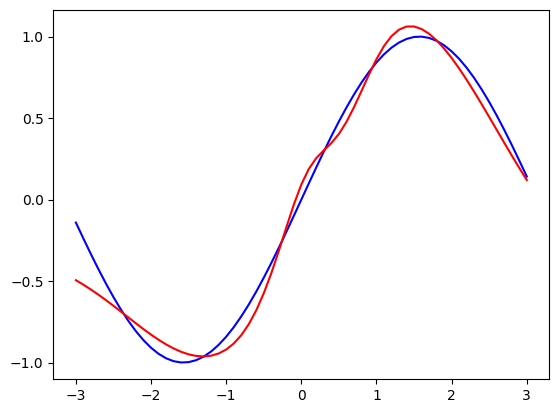

In [ ]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

**4B**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.3003108042045082
2/(50, error=1.0548898577072234
3/(50, error=0.9304706570609322
4/(50, error=0.8638708146033531
5/(50, error=0.7868383439901295
6/(50, error=0.7313659562499852
7/(50, error=0.6831344092246955
8/(50, error=0.6454547721513021
9/(50, error=0.6204269802959741
10/(50, error=0.603378886213128
11/(50, error=0.5902825557557334
12/(50, error=0.5791859752999396
13/(50, error=0.5692348541162952
14/(50, error=0.5599466604096379
15/(50, error=0.5504863731595614
16/(50, error=0.5399871983841212
17/(50, error=0.5245971447155974
18/(50, error=0.49958531498823866
19/(50, error=0.47617127123634356
20/(50, error=0.45922831527742497
21/(50, error=0.4298433585303687
22/(50, error=0.3862357257103297
23/(50, error=0.36024634350367235
24/(50, error=0.343908296046225
25/(50, error=0.33153589439898734
26/(50, error=0.3214912896806551
27/(50, error=0.31288316876822597
28/(50, error=0.3052667405330219
29/(50, error=0.2985489758195627
30/(50, error=0.29270749456932393
31/(50, error=

In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
#!pip install simple-colors
import simple_colors

In [ ]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 8 	true: 9
pred: 6 	true: 5
pred: 7 	true: 9
pred: 0 	true: 0
pred: 0 	true: 6
pred: 4 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 7 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.7
Correct: 14


In [ ]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

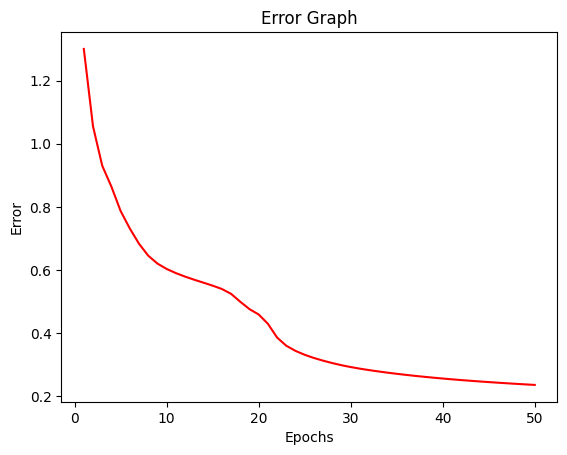

In [ ]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()